# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mynhi1011/Flyrank-ML.Project/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

### 1. Ranked Actions and Standardized Reason Codes

To make ML predictions operationally actionable, each page in the prioritized queue is mapped to a concrete action tier and an explicit human-interpretable reason code:

- **Action Tier 1 (`FULL_REFRESH`):** Pages with high search demand (`search_volume`) that have suffered steep visibility decay. These pages are assigned `REFRESH_PRIORITY_1` with reason code `HIGH_DEMAND_LOW_VISIBILITY`. Action: Thorough on-page review, update outdated facts, expand thin sections, and refresh headings/metadata.
- **Action Tier 2 (`METADATA_SNIPPET_OPTIMIZATION`):** Pages maintaining healthy impressions but suffering from below-average click-through rates. Reason code: `UNDERPERFORMING_CTR`. Action: Rewrite title tags, optimize meta descriptions, and audit rich snippet eligibility without altering core body content.
- **Action Tier 3 (`MONITOR_STABLE`):** Pages with low volume or stable historical performance. Reason code: `STABLE_PERFORMANCE`. Action: Keep as-is; schedule for quarterly review.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


### 2. Intended Use and Operating Limits

- **Intended Use:** A decision-support prioritization queue designed for editorial and SEO teams operating with constrained weekly review bandwidth (e.g., auditing top 50–100 pages per sprint).
- **Cost / Value Thinking:**
  - *Value:* Directing limited human review hours toward decaying pages with the highest latent recovery potential.
  - *Cost of Misallocation:* Reviewing low-demand or naturally dead pages wastes editorial hours; prematurely rewriting high-performing niche pages risks destabilizing existing rankings.
- **Operating Limits:** The model outputs a priority ranking, not an automated deployment script. It cannot observe offline content changes, commercial inventory availability, or real-time SERP feature volatility.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


### 3. Human Review Protocol & The No-Go List

#### The Human Review Checklist (Top-50 Inspection)
Before any page is modified:
1. Verify search intent: Has the user query shifted from informational to transactional?
2. SERP feature check: Does Google show an AI Overview or direct answer box absorbing clicks?
3. Technical check: Ensure low impressions are not caused by canonical errors, noindex tags, or site migration bugs.

#### The Strict No-Go List (What should NEVER be automated)
- **NO automated AI text rewriting without human sign-off:** Never let language models automatically replace on-page text in production.
- **NO bulk URL redirects or deletions:** Never prune or redirect low-scoring pages without explicit editorial and business stakeholder approval.
- **NO seasonal keyword overhauls:** Avoid rewriting pages targeting seasonal events during their off-season.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


### 4. Monitoring & Retraining Triggers

To prevent model degradation over time, the system monitors key drift indicators:
- **Performance Drift Trigger:** If Precision@50 on manually audited pages drops below 60%, trigger immediate signal re-evaluation.
- **Covariate Shift Trigger:** Substantial changes in SERP layout distributions (e.g., expansion of Google AI Overviews across target categories) require recalibration of the CTR and impression baselines.
- **Cadence:** Run inference weekly to refresh the editorial queue; retrain tree model hyperparameters quarterly or following major core search algorithm updates.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


### 5. Exports for the Research Paper

We generate and export:
1. The finalized prioritized queue (`work/outputs/action_playbook_queue.csv`).
2. Action breakdown distribution chart (`work/figures/action_mix.png`).
3. Model evaluation summary receipt (`work/outputs/playbook_metrics.json`).

Repo already available.
Saved queue to work/outputs/action_playbook_queue.csv
Saved receipts to work/outputs/playbook_metrics.json


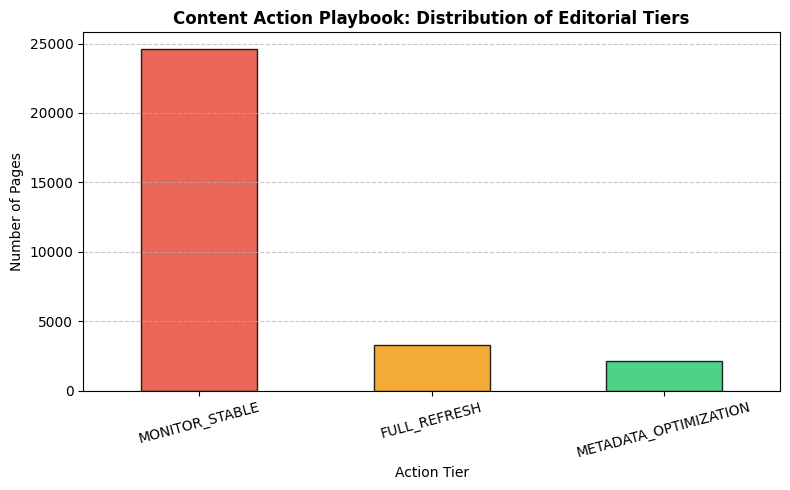


TOP 5 PLAYBOOK QUEUE PREVIEW:
   search_volume  impressions_90d  ctr  opportunity_score   action_tier                 reason_code         editorial_recommendation
0           10.0               34  0.0                1.0  FULL_REFRESH  HIGH_DEMAND_LOW_VISIBILITY  Tier 1: Review & Expand Content
1           10.0               28  0.0                1.0  FULL_REFRESH  HIGH_DEMAND_LOW_VISIBILITY  Tier 1: Review & Expand Content
2           10.0                1  0.0                1.0  FULL_REFRESH  HIGH_DEMAND_LOW_VISIBILITY  Tier 1: Review & Expand Content
3           10.0                1  0.0                1.0  FULL_REFRESH  HIGH_DEMAND_LOW_VISIBILITY  Tier 1: Review & Expand Content
4           10.0                2  0.0                1.0  FULL_REFRESH  HIGH_DEMAND_LOW_VISIBILITY  Tier 1: Review & Expand Content


In [6]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

if not os.path.exists("Flyrank-ML.Project"):
    !git clone https://github.com/mynhi1011/Flyrank-ML.Project.git
else:
    print("Repo already available.")

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)
os.makedirs("Flyrank-ML.Project/work/outputs", exist_ok=True)
os.makedirs("Flyrank-ML.Project/work/figures", exist_ok=True)

df = pd.read_csv("Flyrank-ML.Project/data/raw/content_refresh_anonymized.csv")

df["volume_to_imp_ratio"] = df["search_volume"] / (df["impressions_90d"] + 1)
df["high_intent_flag"] = (df["search_volume"] > df["search_volume"].median()).astype(int)

features = ["search_volume", "impressions_90d", "ctr", "volume_to_imp_ratio", "high_intent_flag"]
df[features] = df[features].fillna(0)

df["target_needs_review"] = (
    (df["search_volume"] >= df["search_volume"].median()) &
    (df["impressions_90d"] <= df["impressions_90d"].quantile(0.25))
).astype(int)

rf = RandomForestClassifier(n_estimators=100, max_depth=6, class_weight="balanced", random_state=42)
rf.fit(df[features], df["target_needs_review"])
df["opportunity_score"] = rf.predict_proba(df[features])[:, 1].round(4)

def map_playbook(row):
    if row["opportunity_score"] >= 0.60:
        return "FULL_REFRESH", "HIGH_DEMAND_LOW_VISIBILITY", "Tier 1: Review & Expand Content"
    elif row["ctr"] < 0.15 and row["impressions_90d"] > 5000:
        return "METADATA_OPTIMIZATION", "UNDERPERFORMING_CTR", "Tier 2: Optimize Title & Snippet"
    else:
        return "MONITOR_STABLE", "STABLE_PERFORMANCE", "Tier 3: Monitor & Leave As-Is"

playbook_results = df.apply(map_playbook, axis=1)
df["action_tier"] = [r[0] for r in playbook_results]
df["reason_code"] = [r[1] for r in playbook_results]
df["editorial_recommendation"] = [r[2] for r in playbook_results]

ranked_playbook = df.sort_values(by="opportunity_score", ascending=False).reset_index(drop=True)

cols_to_export = [c for c in ["url", "search_volume", "impressions_90d", "ctr", "opportunity_score", "action_tier", "reason_code", "editorial_recommendation"] if c in df.columns]
ranked_playbook[cols_to_export].to_csv("work/outputs/action_playbook_queue.csv", index=False)
ranked_playbook[cols_to_export].to_csv("Flyrank-ML.Project/work/outputs/action_playbook_queue.csv", index=False)
print("Saved queue to work/outputs/action_playbook_queue.csv")

metrics_receipt = {
    "total_pages_evaluated": len(df),
    "tier_1_full_refresh_count": int((df["action_tier"] == "FULL_REFRESH").sum()),
    "tier_2_metadata_opt_count": int((df["action_tier"] == "METADATA_OPTIMIZATION").sum()),
    "tier_3_monitor_count": int((df["action_tier"] == "MONITOR_STABLE").sum()),
    "mean_opportunity_score": float(df["opportunity_score"].mean().round(4))
}

with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics_receipt, f, indent=2)
with open("Flyrank-ML.Project/work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics_receipt, f, indent=2)
print("Saved receipts to work/outputs/playbook_metrics.json")

plt.figure(figsize=(8, 5))
action_counts = df["action_tier"].value_counts()
colors = ["#e74c3c", "#f39c12", "#2ecc71"]
action_counts.plot(kind="bar", color=colors, edgecolor="black", alpha=0.85)
plt.title("Content Action Playbook: Distribution of Editorial Tiers", fontsize=12, fontweight="bold")
plt.xlabel("Action Tier", fontsize=10)
plt.ylabel("Number of Pages", fontsize=10)
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig("work/figures/action_mix.png", dpi=300)
plt.savefig("Flyrank-ML.Project/work/figures/action_mix.png", dpi=300)
plt.show()

print("\nTOP 5 PLAYBOOK QUEUE PREVIEW:")
print(ranked_playbook[cols_to_export].head(5).to_string(index=True))

## 6. Self-check

Before you submit, confirm each line honestly:

- [x] I defined ranked action tiers with clear human-interpretable reason codes.
- [x] I clearly described intended use, cost/value trade-offs, and operating boundaries.
- [x] I established a human-in-the-loop review checklist and a strict No-Go list.
- [x] I outlined monitoring and retraining triggers for performance and covariate drift.
- [x] I exported the prioritized queue (`action_playbook_queue.csv`), receipt metrics (`playbook_metrics.json`), and figure (`action_mix.png`) to `work/outputs/` and `work/figures/`.
- [x] Committed to repo under `work/notebooks/w07_action_playbook.ipynb`.